In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm, lognorm
import matplotlib.pyplot as plt

All the fragility models are defined in terms of lognormal functions, with a median and a dispersion parameter for each damage state.

## Building fragility

### Use the cell below to adjust the fragility parameters and observe the fragility plots below

In [6]:
# Basement
median_basement_limit_state = 1.0 # feet
disp_basement = 0.1

# 1st Floor
median_floor1_limit_state = 3.0 # feet
disp_floor1 = 0.2

# 2nd Floor
median_floor2_limit_state = 13.0 # feet
disp_floor2 = 0.2

### Plot the fragility curve

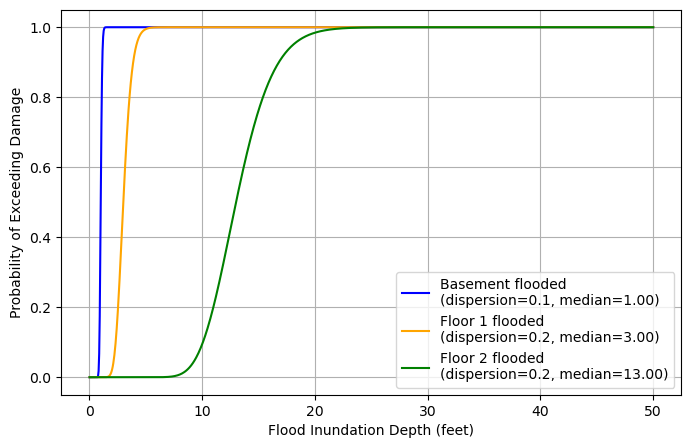

In [8]:
# Generate x values
ims = np.linspace(0.01, 50.0, 1000)

# Compute CDF
frag1 = lognorm.cdf(ims, disp_basement, scale=median_basement_limit_state)
frag2 = lognorm.cdf(ims, disp_floor1, scale=median_floor1_limit_state)
frag3 = lognorm.cdf(ims, disp_floor2, scale=median_floor2_limit_state)

# Plot CDF
plt.figure(figsize=(8, 5))
plt.plot(ims, frag1, label=f'Basement flooded\n(dispersion={disp_basement}, median={median_basement_limit_state:.2f})', color='b')
plt.plot(ims, frag2, label=f'Floor 1 flooded\n(dispersion={disp_floor1}, median={median_floor1_limit_state:.2f})', color='orange')
plt.plot(ims, frag3, label=f'Floor 2 flooded\n(dispersion={disp_floor2}, median={median_floor2_limit_state:.2f})', color='green')

plt.xlabel('Flood Inundation Depth (feet)')
plt.ylabel('Probability of Exceeding Damage')
plt.legend()
plt.grid()
plt.show()

In [9]:
classes = ['num_floors_le_1', 'num_floors_ge_2']

damage_states = {'num_floors_le_1': ['basement_flooded', 'floor_1_flooded'],
                 'num_floors_ge_2': ['basement_flooded', 'floor_1_flooded', 'floor_2_flooded'],
                }    

In [10]:
# building_fragility_df = pd.DataFrame()
# class_list = []
# ls_list = []
# med_list = []
# disp_list = []

# for class_val in classes:
#     for floor_num, ds in enumerate(damage_states[class_val]):
#         class_list.append(class_val)
#         ls_list.append(ds)
#         if floor_num == 0:
#             median_depth = median_basement_limit_state
#             disp = disp_basement
#         elif floor_num == 1:
#             median_depth = median_floor1_limit_state
#             disp = disp_floor1
#         elif floor_num == 2:
#             median_depth = median_floor2_limit_state
#             disp = disp_floor2

#         med_list.append(median_depth)
#         disp_list.append(disp)

# building_fragility_df['Class'] = class_list
# building_fragility_df['Damage State'] = ls_list
# building_fragility_df['Median'] = med_list
# building_fragility_df['Dispersion'] = disp_list
# building_fragility_df

In [11]:
# create a fragility curve set with three limit state
fragility_curve_basement = {
    "description": "Basement Submerged",
    "rules": [
        {
            "condition": [
                "inundationDepth > 0"
            ],
            "expression": "scipy.stats.norm.cdf((math.log(inundationDepth) - {})/({}))".format(np.log(median_basement_limit_state), disp_basement)
        }
    ],
    "returnType": {
        "type": "Limit State",
        "unit": "",
        "description": "basement_flooded"
    }
}

fragility_curve_FL_1 = {
    "description": "First Floor Submerged",
    "rules": [
        {
            "condition": [
                "inundationDepth > 0"
            ],
            "expression": "scipy.stats.norm.cdf((math.log(inundationDepth) - {})/({}))".format(np.log(median_floor1_limit_state), disp_floor1)
        }
    ],
    "returnType": {
        "type": "Limit State",
        "unit": "",
        "description": "Floor1_flooded"
    }
}

fragility_curve_FL_2 = {
    "description": "Second Floor Submerged",
    "rules": [
        {
            "condition": [
                "inundationDepth > 0"
            ],
            "expression": "scipy.stats.norm.cdf((math.log(inundationDepth) - {})/({}))".format(np.log(median_floor2_limit_state), disp_floor2)
        }
    ],
    "returnType": {
        "type": "Limit State",
        "unit": "",
        "description": "Floor2_flooded"
    }
}

## Road Fragility

In [13]:
# Basement
median_road = 1.0 # feet
disp_road = 0.1

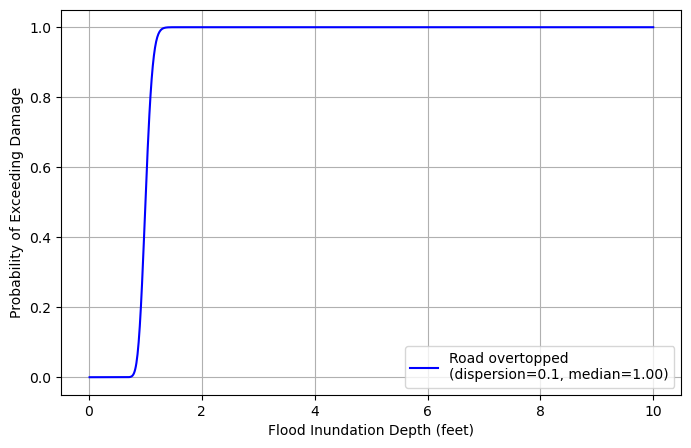

In [14]:
# Generate x values
ims = np.linspace(0.01, 10.0, 1000)

# Compute CDF
frag1 = lognorm.cdf(ims, disp_road, scale=median_road)

# Plot CDF
plt.figure(figsize=(8, 5))
plt.plot(ims, frag1, label=f'Road overtopped\n(dispersion={disp_road}, median={median_road:.2f})', color='b')

plt.xlabel('Flood Inundation Depth (feet)')
plt.ylabel('Probability of Exceeding Damage')
plt.legend()
plt.grid()
plt.show()

In [15]:
# classes = ['all_roads']

# damage_states = {'all_roads': ['road_overtopped'],
#                 }    

In [16]:
# road_fragility_df = pd.DataFrame()
# class_list = []
# ls_list = []
# med_list = []
# disp_list = []

# for class_val in classes:
#     for floor_num, ds in enumerate(damage_states[class_val]):
#         class_list.append(class_val)
#         ls_list.append(ds)
#         median_depth = median_road
#         disp = disp_road

#         med_list.append(median_depth)
#         disp_list.append(disp)

# road_fragility_df['Class'] = class_list
# road_fragility_df['Damage State'] = ls_list
# road_fragility_df['Median'] = med_list
# road_fragility_df['Dispersion'] = disp_list
# road_fragility_df

In [17]:
# create a fragility curve set with three limit state
fragility_curve_roadway = {
    "description": "Road Submerged",
    "rules": [
        {
            "condition": [
                "inundationDepth > 0"
            ],
            "expression": "scipy.stats.norm.cdf((math.log(inundationDepth) - {})/({}))".format(np.log(median_road), disp_road)
        }
    ],
    "returnType": {
        "type": "Limit State",
        "unit": "",
        "description": "road_overtopped"
    }
}

## Substation Fragility

In [19]:
# Basement
median_substation = 10.0 # feet
disp_substation = 0.1

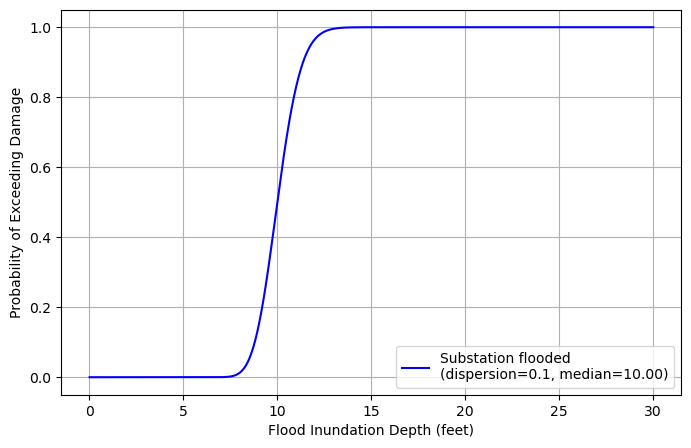

In [20]:
# Generate x values
ims = np.linspace(0.01, 30.0, 1000)

# Compute CDF
frag1 = lognorm.cdf(ims, disp_substation, scale=median_substation)

# Plot CDF
plt.figure(figsize=(8, 5))
plt.plot(ims, frag1, label=f'Substation flooded\n(dispersion={disp_substation}, median={median_substation:.2f})', color='b')

plt.xlabel('Flood Inundation Depth (feet)')
plt.ylabel('Probability of Exceeding Damage')
plt.legend()
plt.grid()
plt.show()

In [21]:
# classes = ['all_substations']

# damage_states = {'all_substations': ['substation_flooded'],
#                 }   

In [22]:
# substation_fragility_df = pd.DataFrame()
# class_list = []
# ls_list = []
# med_list = []
# disp_list = []

# for class_val in classes:
#     for floor_num, ds in enumerate(damage_states[class_val]):
#         class_list.append(class_val)
#         ls_list.append(ds)
#         median_depth = median_substation
#         disp = disp_substation

#         med_list.append(median_depth)
#         disp_list.append(disp)

# substation_fragility_df['Class'] = class_list
# substation_fragility_df['Damage State'] = ls_list
# substation_fragility_df['Median'] = med_list
# substation_fragility_df['Dispersion'] = disp_list
# substation_fragility_df

In [23]:
# create a fragility curve set with three limit state
fragility_curve_substation = {
    "description": "Substation Submerged",
    "rules": [
        {
            "condition": [
                "inundationDepth > 0"
            ],
            "expression": "scipy.stats.norm.cdf((math.log(inundationDepth) - {})/({}))".format(np.log(median_substation), disp_substation)
        }
    ],
    "returnType": {
        "type": "Limit State",
        "unit": "",
        "description": "water_in_substation"
    }
}